In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

In [2]:
df = pd.read_csv("../data/clean_movie_comments.csv")

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (4775, 5)


,Video ID,Cleaned Comment,Movie Rating,Volgur Comment,Movie Category
0,JZMT84XFbSk,this movie is excellent bro..niku anil ravipud...,Excellent,No,Not Able to Judge
1,JZMT84XFbSk,"Its full family movie ra , stop seeing crime a...",Neutral,No,Not Able to Judge
2,JZMT84XFbSk,Exactly second half lo comedy scenes were too ...,Very Good,No,Not Able to Judge
3,JZMT84XFbSk,Super movie.go watch it,Very Good,No,Not Able to Judge
4,JZMT84XFbSk,First half avg. Emotional sequence in Second h...,Neutral,No,Not Able to Judge


In [3]:
pipeline = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(max_features=5000)
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42
        )
    )
])

In [4]:
scores = cross_val_score(
    pipeline,
    df["Cleaned Comment"],
    df["Movie Rating"],
    cv=5,
    scoring="accuracy"
)

In [7]:
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    pipeline,
    df["Cleaned Comment"],
    df["Movie Rating"],
    cv=cv,
    scoring="accuracy"
)

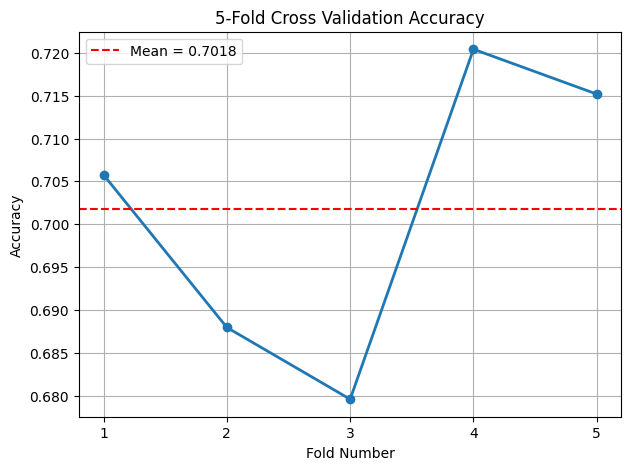

In [8]:
plt.figure(figsize=(7,5))

plt.plot(
    range(1,6),
    scores,
    marker="o",
    linewidth=2
)

plt.axhline(
    scores.mean(),
    color="red",
    linestyle="--",
    label=f"Mean = {scores.mean():.4f}"
)

plt.xticks(range(1,6))

plt.xlabel("Fold Number")

plt.ylabel("Accuracy")

plt.title("5-Fold Cross Validation Accuracy")

plt.grid(True)

plt.legend()

plt.show()

In [9]:
from sklearn.model_selection import cross_validate

results = cross_validate(
    pipeline,
    df["Cleaned Comment"],
    df["Movie Rating"],
    cv=cv,
    scoring=[
        "accuracy",
        "f1_macro",
        "f1_weighted"
    ]
)

print("Mean Accuracy :", results["test_accuracy"].mean())
print("Mean Macro F1 :", results["test_f1_macro"].mean())
print("Mean Weighted F1 :", results["test_f1_weighted"].mean())

Mean Accuracy : 0.7017801047120418
Mean Macro F1 : 0.6403337252505533
Mean Weighted F1 : 0.7103824552444555
